In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import missingno as msno

In [5]:
df = pd.read_csv("../data/processed/merged/merged_data.csv",parse_dates=['Date'], index_col='Date') 

# 1.Basic Overview 

In [6]:
df.head()

,gold_close,gold_high,gold_low,gold_open,gold_vol,dxy_close,vix_close,yield_close,sp500_close,oil_close
Date,,,,,,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138,91.080002,17.790001,2.123,2058.199951,52.689999
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470,91.379997,19.920000,2.039,2020.579956,50.040001
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97,91.500000,21.120001,1.963,2002.609985,47.930000
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29,91.889999,19.309999,1.954,2025.900024,48.650002
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92,92.370003,17.010000,2.016,2062.139893,48.790001


In [7]:
print(f"shape = {df.shape}")

shape = (2825, 10)


In [8]:
print(df.dtypes)

gold_close     float64
gold_high      float64
gold_low       float64
gold_open      float64
gold_vol         int64
dxy_close      float64
vix_close      float64
yield_close    float64
sp500_close    float64
oil_close      float64
dtype: object


In [9]:
df.isnull().sum()

gold_close     0
gold_high      0
gold_low       0
gold_open      0
gold_vol       0
dxy_close      0
vix_close      0
yield_close    0
sp500_close    0
oil_close      0
dtype: int64

In [10]:
print(df.duplicated().sum())

0


In [11]:
df.describe().T.round(2) # Basic Statistics

,count,mean,std,min,25%,50%,75%,max
gold_close,2825.0,1837.23,796.80,1050.80,1273.70,1719.50,1955.30,5318.40
gold_high,2825.0,1847.05,804.89,1062.00,1279.20,1728.10,1963.50,5586.20
gold_low,2825.0,1827.13,788.63,1046.20,1269.90,1708.70,1945.30,5301.60
gold_open,2825.0,1837.09,797.44,1053.70,1274.40,1718.80,1953.20,5415.70
gold_vol,2825.0,5136.59,28054.73,0.00,53.00,207.00,642.00,386334.00
dxy_close,2825.0,98.32,4.82,88.59,94.83,97.62,101.74,114.11
vix_close,2825.0,18.38,7.09,9.14,13.62,16.60,21.29,82.69
yield_close,2825.0,2.68,1.14,0.50,1.78,2.41,3.83,4.99
sp500_close,2825.0,3685.90,1393.23,1829.08,2508.24,3348.42,4499.38,6978.60
oil_close,2825.0,62.46,17.37,-37.63,49.63,61.50,73.17,123.70


# 2.Distribution Analysis

In [12]:
cols = ['gold_close','dxy_close','vix_close','yield_close','sp500_close','oil_close']

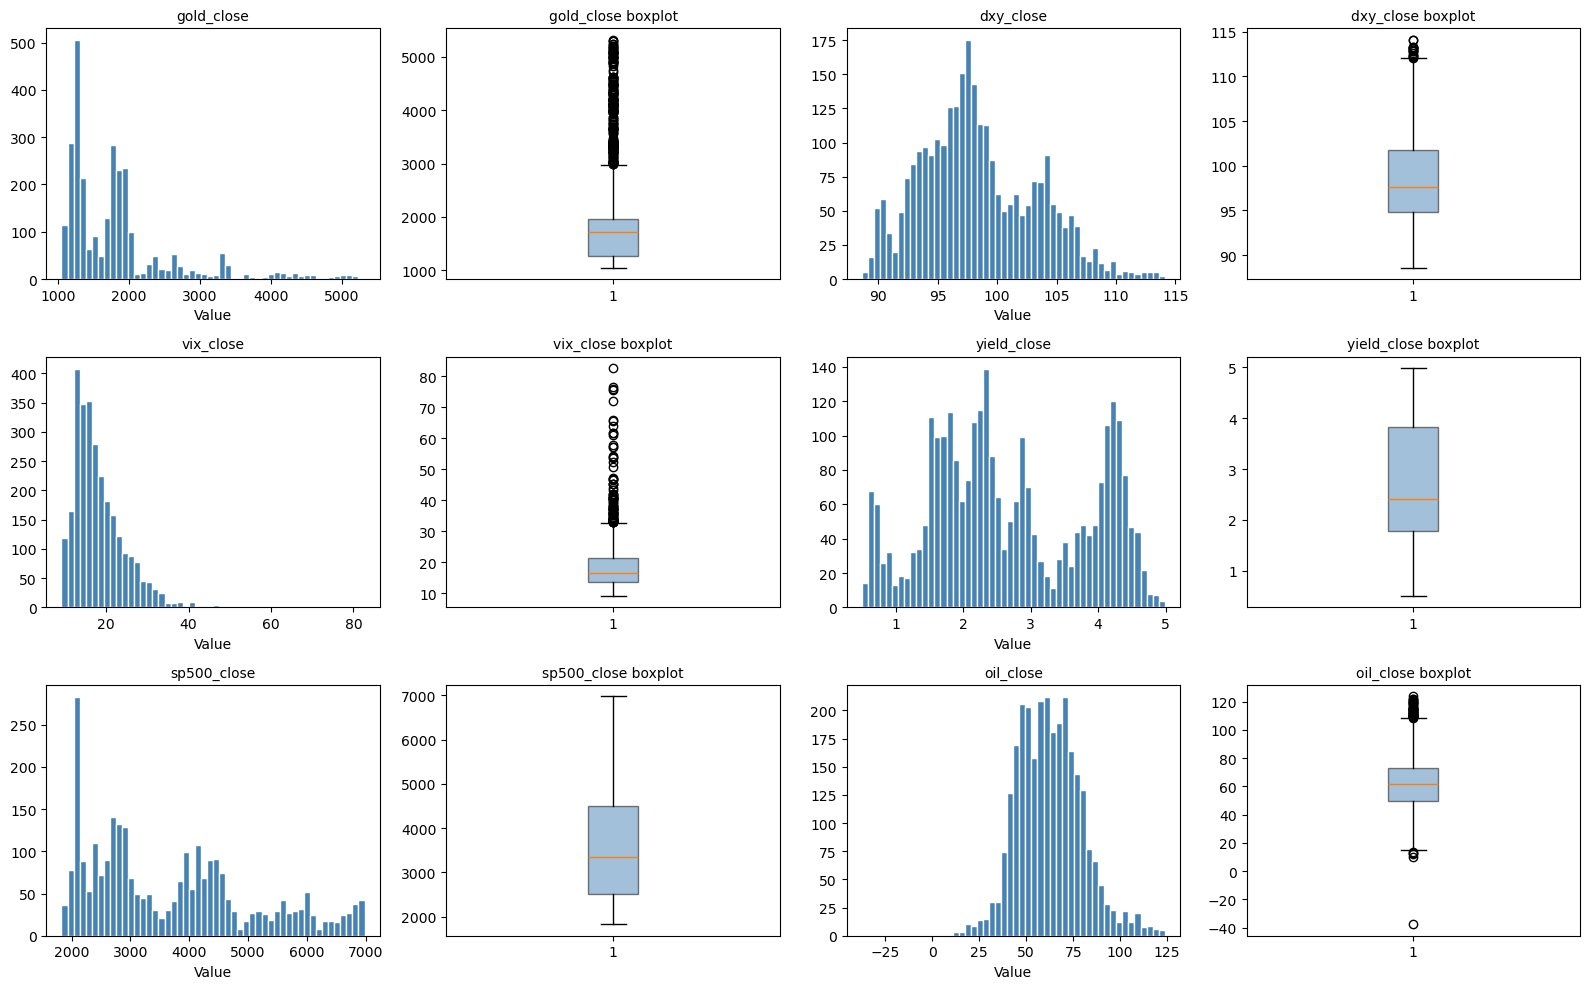

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Histogram
    axes[i*2].hist(df[col].dropna(), bins=50, edgecolor='white', color='steelblue')
    axes[i*2].set_title(col, fontsize=10)
    axes[i*2].set_xlabel('Value')

    # Boxplot
    axes[i*2+1].boxplot(df[col].dropna(), patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i*2+1].set_title(f'{col} boxplot', fontsize=10)

plt.tight_layout()
plt.show()

### Skewness & Kurtosis

- Skewness = ดูความเบ้

    ค่า = 0 -> ข้อมูลสมมาตร 

    ค่า > 0 -> ข้อมูลเบ้ขวา -> ยิ่งมาก -> ยิ่งมี outlier ด้านขวาเยอะ

    ค่า < 0 -> ข้อมูลเบ้ซ้าย -> ยิ่งติดลบมาก -> ยิ่งมี outlier ด้านซ้ายเยอะ
    
โดยถ้า |ค่า skewness| 

        ใกล้ 0 = ดี / สมมาตร

        -0.5 ถึง 0.5 = ค่อนข้างปกติ

        0.5 ถึง 1 = เบ้พอสมควร

        มากกว่า 1 =	เบ้มาก

        มากกว่า 2 = เบ้รุนแรง


- Kurtosis = ดูว่าข้อมูลมี outlier เยอะแค่ไหน

    Kurtosis = 0 ->ใกล้เคียง Normal Distribution -> ดี

    Kurtosis > 0 -> ยอดแหลม,หางหนัก -> ยิ่งมาก -> outlier เยอะ

    Kurtosis < 0 -> ยอดแบน,หางเบา -> ยิ่งติดลบมาก -> outlier น้อย -> ข้อมูลนิ่ง
    


In [14]:
print("Skewness & Kurtosis:")
for col in cols:
    sk = df[col].skew()
    ku = df[col].kurtosis()
    print(f"  {col:<20} skew={sk:+.2f}  kurt={ku:+.2f}")

Skewness & Kurtosis:
  gold_close           skew=+2.01  kurt=+4.24
  dxy_close            skew=+0.47  kurt=-0.20
  vix_close            skew=+2.60  kurt=+13.14
  yield_close          skew=+0.15  kurt=-1.09
  sp500_close          skew=+0.66  kurt=-0.58
  oil_close            skew=+0.34  kurt=+0.76


* ผลการวิเคราะห์

        gold_close   -> เบ้ขวามาก เเละ มี outlier มาก        
        dxy_close    -> ปกติ        
        vix_close    -> เบ้ขวามาก เเละ มี outlier มากๆๆๆ         
        yield_close  -> ปกติ
        sp500_close  -> เบ้ขวาเล็กน้อย
        oil_close    -> ปกติ เเละ มี outlier บ้าง

In [15]:
# Outlier count (IQR method)
print("\nOutliers (IQR method):")
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f"  {col:<20} {n_out} rows")


Outliers (IQR method):
  gold_close           262 rows
  dxy_close            17 rows
  vix_close            91 rows
  yield_close          0 rows
  sp500_close          0 rows
  oil_close            46 rows


# 3.Time Series Analysis

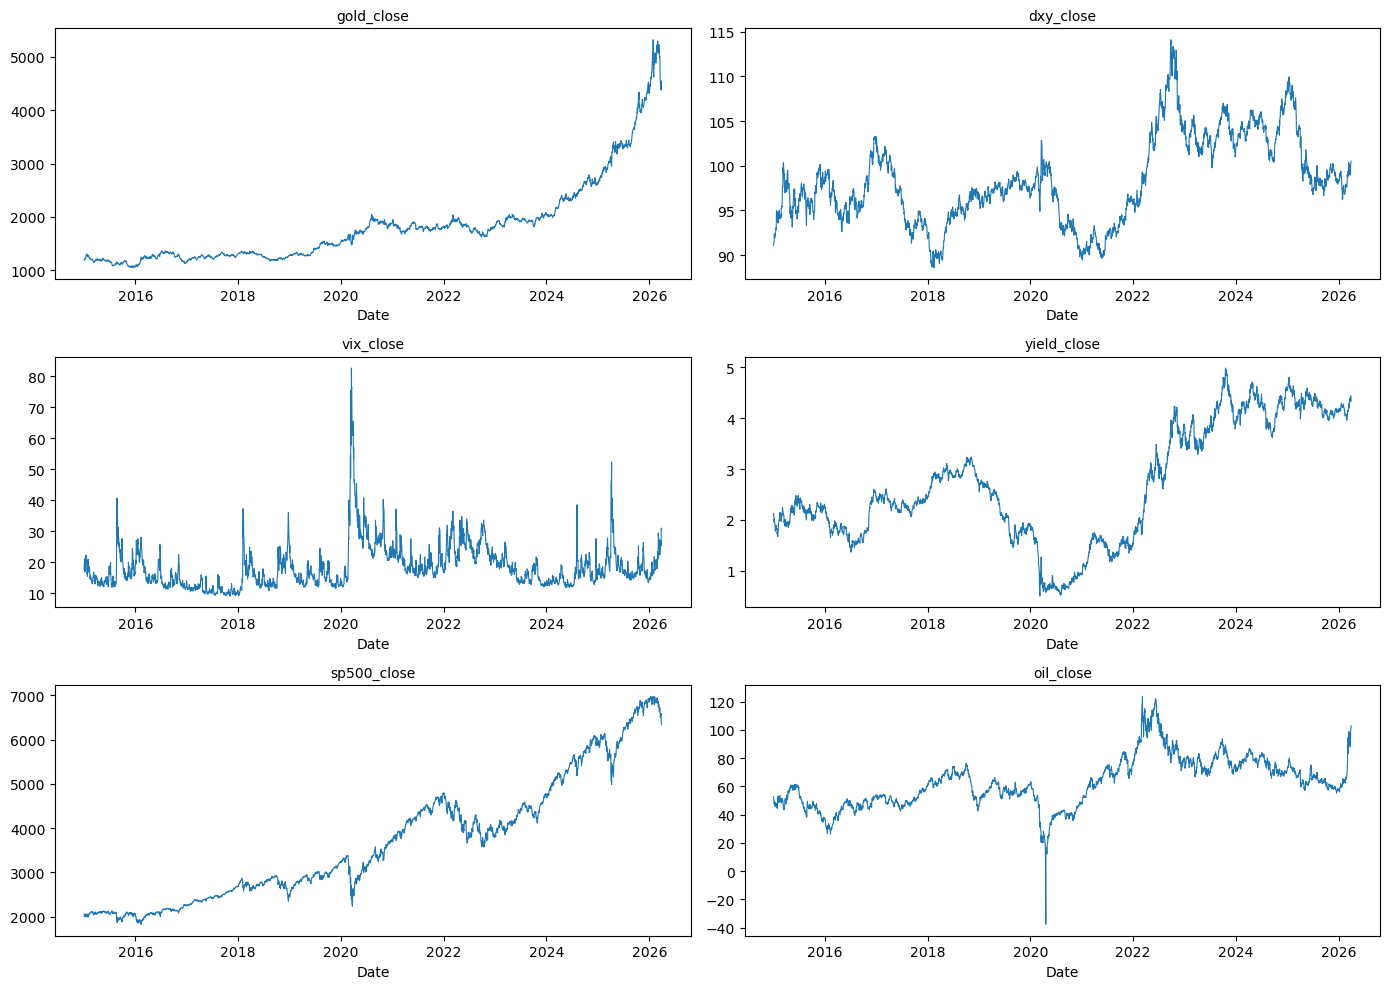

In [16]:
# Plot price over time
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].plot(df.index, df[col], linewidth=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Date')
plt.tight_layout()
plt.show()


* สรุป graph Price Over Time เเต่ละอัน

        -gold เเนวโน้มในระยะยาวเป็นขาขึ้น โดยตั้งเเต่ปี 2024 เป็นต้นมาจะสังเกตุได้ว่าราคาพุ่งขึ้นอย่างรวดเร็วมาก

        -dxy ผันผวนสูง

        -vix มีช่วงพุ่งสูงเป็นระยะๆ เเละในช่วงประมาณ 2020 พุ่งสูงมาก ซึ่งตรงกับการลดลงของราคาในตลาด s&p500

        -yield โดยปกติถ้า yield สูง ราคาทองจะต้องลดลง เเต่ตั้งเเต่ในช่วงของปี 2024 ราคาทองสูงขึ้นในขณะที่ yield ยังคงลอยตัวสูงเท่าๆเดิม

        -sp500 เเนวโน้มในระยะยาวเป็นขาขึ้น

        -oil มีช่วงที่ลงต่ำผิดปกติ ซึ่งเป็นจุดที่เเสดงให้เห็นถึงมีจุด Outlier ที่ชัดเจนมากตรงกับในปี 2020  เเละมีช่วงที่อยู่ดีๆพุ่งเร็วมาก ซึ่งราคาน้ำมันมักเป็นตัวแทนของทิศทาง "เงินเฟ้อ" (Inflation) ซึ่งทองคำมักถูกใช้เป็นสินทรัพย์ป้องกันเงินเฟ้อ

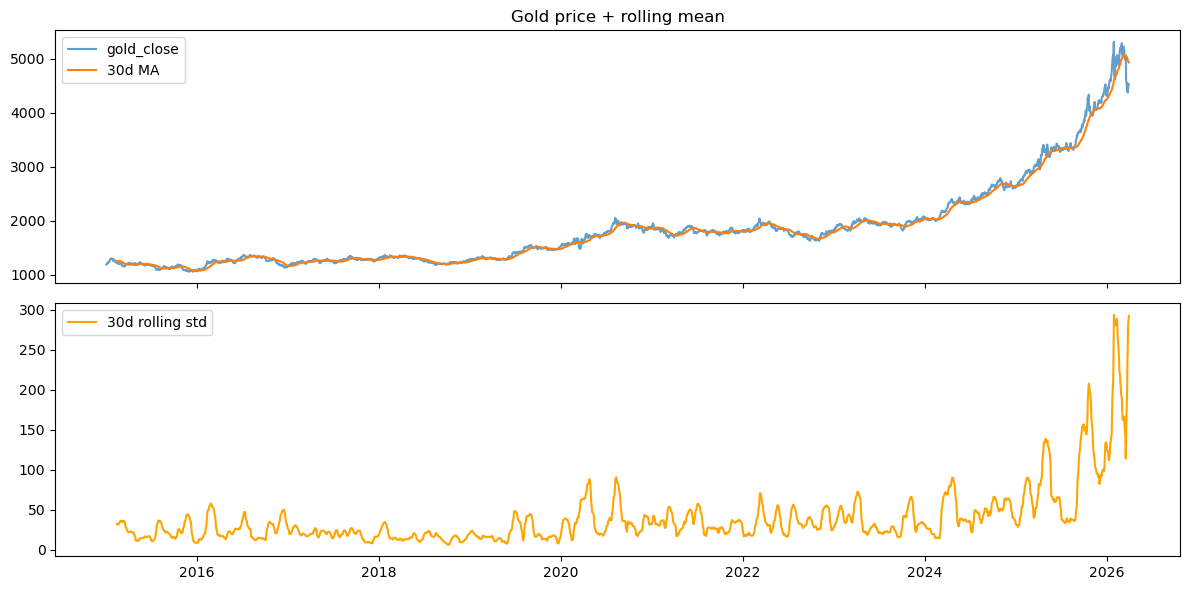

In [17]:
# Gold with rolling mean & std
window = 30
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df['gold_close'], label='gold_close', alpha=0.7)
axes[0].plot(df['gold_close'].rolling(window).mean(), label=f'{window}d MA', linewidth=1.5)
axes[0].legend()
axes[0].set_title('Gold price + rolling mean')

axes[1].plot(df['gold_close'].rolling(window).std(), color='orange', label=f'{window}d rolling std')
axes[1].legend()
plt.tight_layout()
plt.show()

* กราฟ 30d MA

    จากกราฟจะเห็นได้ว่าราคาของทองเมื่อวิ่งออกจากเส้น 30d MA หรือ กราฟเส้นเฉลี่ยราคาทอง 30 วัน จะมีเเนวโน้มดึงกลับเข้าหาเส้น 30 d MA เสมอ

* กราฟ 30d rolling mean std

    จากกราฟจะเห็นได้ว่าในช่วงปี 2015 ถึงปลายปี 2024 จะยังมีค่า S.D. ในข่วงประมาณเดิม เเต่หลังจากนั้นช่วงปี 2024-2026 มีค่า S.D. ที่ขึ้นลงสูงมาก ซึ่งเเสดงให่้เห็นถึงความผันผวนของราคาทองที่สูงมาก


In [18]:
# ADF Test (Stationarity)
print("ADF Test (Stationarity):")
for col in cols:
    res = adfuller(df[col].dropna())
    stat = "Stationary" if res[1] < 0.05 else "Non-stationary"
    print(f"  {col:<20} p={res[1]:.4f}  → {stat}")

ADF Test (Stationarity):
  gold_close           p=0.9991  → Non-stationary
  dxy_close            p=0.1383  → Non-stationary
  vix_close            p=0.0000  → Stationary
  yield_close          p=0.8194  → Non-stationary
  sp500_close          p=0.9618  → Non-stationary
  oil_close            p=0.3278  → Non-stationary


* ADF Test คือตัววัดความนิ่ง(stationary)ของข้อมูล โดยที่ความนิ่ง คือ ข้อมูลที่มีคุณสมบัติทางสถิติคงที่เมื่อเวลาผ่านไป

    ซึ่งจะดูว่าข้อมูลชุดนั้นนิ่งหรือไม่นิ่งดูจากค่า p-value โดยถ้า p<0.05 จะเเสดงว่าข้อมูลนนั้น stationary หรือ นิ่งนั่นเอง 
    
    โดยจากผลลัพธ์พบว่ามีเเค่ข้อมูล vix_close เท่านั้นที่ stationary เเต่ในส่วนชุดข้อมูลอื่นๆเป็น non-stationary ซึ่งเป็นปกติสำหรับข้อมูลราคาสินทรัพย์เเละในส่วนของเปอร์เซ็นต์ผลตอบเเทนพันธบัตรรัฐบาลสหรัฐ อายุ 10 ปี (US 10-Year Treasury Yield)

# 4.Correlation Analysis

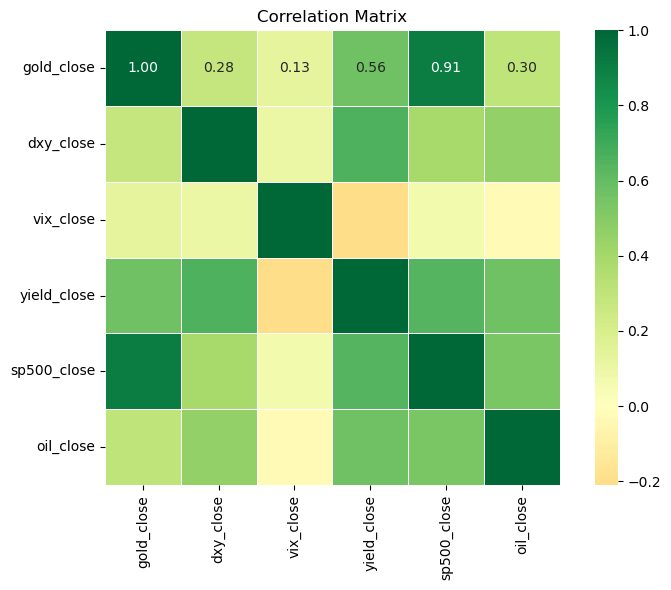

In [19]:
# Correlation matrix heatmap
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

* Correlation matrix heatmap
จากกราฟพบว่า
1. เมื่อผลตอบแทนพันธบัตรรัฐบาล (Yield) สูงขึ้น มักจะดึงดูดเม็ดเงินลงทุนเข้าประเทศ ทำให้ค่าเงินดอลลาร์ (DXY) แข็งค่าตามไปด้วย การที่สองตัวนี้มีความสัมพันธ์กันปานกลางค่อนข้างสูงอาจจะต้องระวังเรื่อง Multicollinearity (ตัวแปรต้นมีความสัมพันธ์กันเองสูงเกินไปจนโมเดลสับสน)
2. Vix ไม่ขึ้นอยู่กับข้อมูลชนิดอื่นๆเนื่องจากมีค่า Correlation กับชุดข้อมูล ที่ต่ำมากๆ
3. gold กับ s&p500 มีความสัมพันธ์ที่สูงมาก เเต่เนื่องจากถ้าดู trend ในระยะยาวจะพบว่าเป็นขาขึ้นเหมือนกัน นั่นคงเป็นเหตุผลที่ว่ามีค่า correlation สูงถึง 0.91

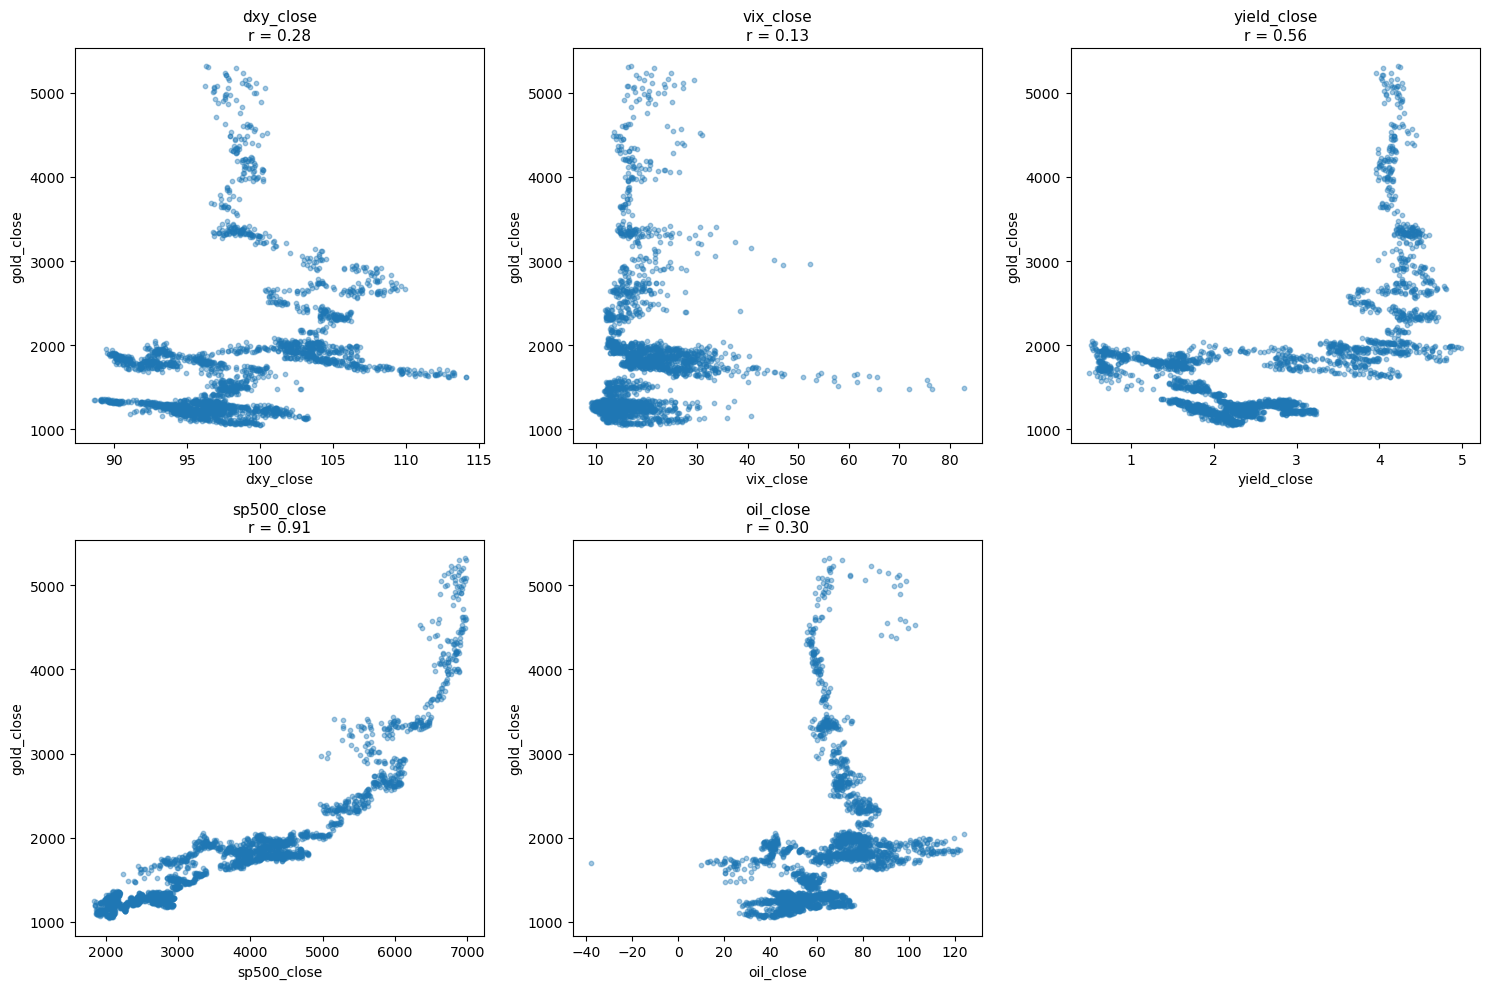

In [20]:
# Scatter plots: gold vs others 
other_cols = [c for c in cols if c != 'gold_close']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(other_cols):
    axes[i].scatter(
        df[col],
        df['gold_close'],
        alpha=0.4,
        s=10
    )

    r, p = stats.pearsonr(
        df[col].dropna(),
        df['gold_close'].loc[df[col].notna()]
    )

    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('gold_close', fontsize=10)
    axes[i].set_title(f'{col}\nr = {r:.2f}', fontsize=11)

# ถ้ามีช่องว่างเหลือ ให้ลบทิ้ง
for j in range(len(other_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* จาก Scatter Plot 
1. ในส่วนของ dxy กับ gold ข้อมูลไม่ได้เรียงเป็นเส้น แต่เกาะกลุ่มกันเป็นก้อนๆ (Clusters) แปลว่าความสัมพันธ์ของดอลลาร์กับทองคำนั้นเปลี่ยนไปมาตามยุคสมัย ไม่สามารถใช้กฎตายตัวข้อเดียวมาอธิบายได้
2. ในส่วนของ s&p500 กับ gold จะสังเกตุเห็นว่าปลายกราฟด้านบนขวา ราคาทองคำพุ่งทะยานขึ้นอย่างรวดเร็วเกือบจะเป็นแนวตั้งฉาก ในขณะที่ดัชนี SP500 แทบไม่ได้ขยับไปทางขวาเพิ่มขึ้นเท่าไหร่เลย ทำให้เห็นได้ว่าความสัมพันธ์ของ 2 สิ่งนี้เปลี่ยนไปแล้วในช่วงหลัง ซึ่งอาจจะไม่สามารถใช้ Linear Regression ตรงๆได้
3. ปกติตามทฤษฎีคือ ถ้า yield ขึ้น ทองต้องลง แต่จากกราฟพบว่า ทางขวาสุดของกราฟ เรียงกันเป็นเเท่งเเนวตั้ง นั่นคือช่วงที่yield พุ่งไปแตะระดับ 4-5% (สูงมาก) แต่ราคาทองคำกลับไม่ได้ลงลดลงเลย เเต่กลับพุ่งสวนขึ้นไปทำ All-time High นี่คือสัญญาณว่าตลาดมีสภาวะที่แปลกไป
4. มีในส่วนของ oil ที่เห็นว่าเป็น outllier 1 จุดได้อย่างชัดเจน คือตรงในส่วนที่เเกน x มีค่าอยู่ที่ประมาณ -40 (อย่าลืมลบค่าตรงนี้ออกก่อนไป train)

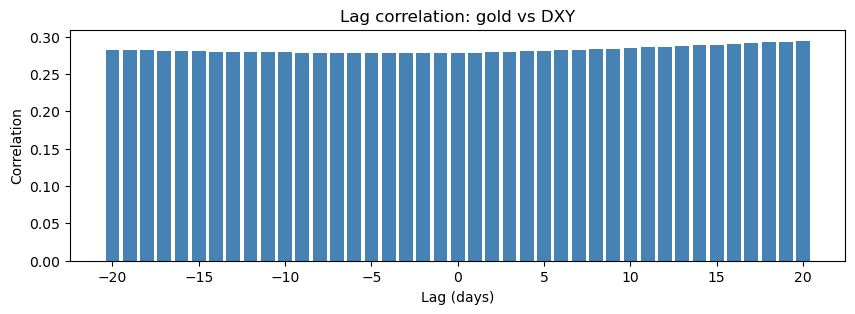

In [21]:
# Lag correlation: gold vs dxy (up to 20 lags)
lags = range(-20, 21)
lag_corr = [df['gold_close'].corr(df['dxy_close'].shift(lag)) for lag in lags]
plt.figure(figsize=(10, 3))
plt.bar(lags, lag_corr, color=['red' if x < 0 else 'steelblue' for x in lag_corr])
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Lag (days)')
plt.ylabel('Correlation')
plt.title('Lag correlation: gold vs DXY')
plt.show()

* Lag correlation
1. จะเห็นว่าไม่ว่าจะเลื่อน (Shift) ข้อมูล DXY ไปข้างหน้า (Lag บวก) หรือย้อนหลัง (Lag ลบ) ตั้งแต่ -20 ถึง +20 วัน ค่าความสัมพันธ์มันแทบจะเท่ากันหมดเลย คือกองๆ กันอยู่ที่ประมาณ $0.28$ ถึง $0.29$ ไม่มีแท่งไหนที่โดดเด่น (Spike) ขึ้นมาอย่างชัดเจนเลย

สิ่งที่ควรเเก้ คือ ต้องแปลงข้อมูลราคา ให้เป็น % Return หรือผลต่างรายวัน (Differencing) ก่อนทำ Lag Correlation 

# 5.Volatility Analysis

In [22]:
# Daily returns
df['gold_return'] = df['gold_close'].pct_change()
df['sp500_return'] = df['sp500_close'].pct_change()

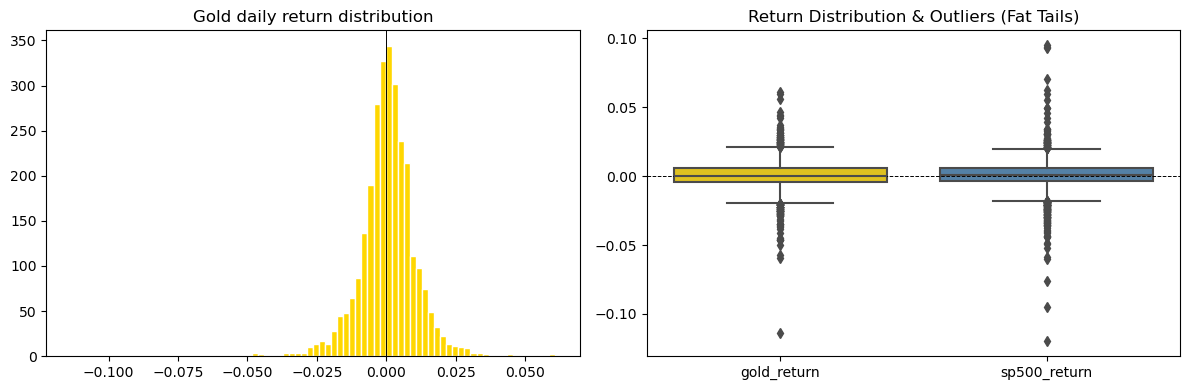

In [23]:
# Histogram & Boxplot of returns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gold daily return distribution (โค้ดเดิมของคุณ)
axes[0].hist(df['gold_return'].dropna(), bins=80, edgecolor='white', color='gold')
axes[0].set_title('Gold daily return distribution')
axes[0].axvline(0, color='black', linewidth=0.7)

# Boxplot เปรียบเทียบความผันผวนและ Outliers
sns.boxplot(data=df[['gold_return', 'sp500_return']].dropna(), ax=axes[1], palette=['gold', 'steelblue'])
axes[1].set_title('Return Distribution & Outliers (Fat Tails)')
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--') 

plt.tight_layout()
plt.show()

* จากกราฟ Histogram of return
1. พบว่ากราฟจะดูคล้ายระฆังคว่ำ แต่ฐานที่ลากยาวออกไปซ้ายขวามากกว่าปกติ เช่น วันที่มีข่าวสงคราม Return อาจจะกระโดดไป +3% หรือ -3% ในวันเดียว(-0.03 กับ 0.03) ซึ่งเป็นจุดที่โมเดล Regression มักจะทำนายพลาดเพราะมันเป็น Extreme Events
2. อาจส่งผลกระทบต่อโมเดล classification เนื่องจากถ้า return มากกว่า 0 เพียงเเค่ 0.01 โมเดลจะมองว่าเป็นขาขึ้นในทันที ดังนั้นควรกำหนด range ของ %return ใหม่
3. อาจส่งผลต่อโมเดล regression ในการทำนายเนื่องจากมีค่าประมาณ0 อยู่มากดังนั้นโมเดลอาจทำนายว่าเป็น 0เพื่อจะใหม่มีค่า RMSE ต่ำ

* Boxplot of returns
1. ตรงกลางของ Boxplot จะเห็นว่าทั้ง gold_return และ sp500_return มีขนาดกล่องที่แบนและแคบมาก เกาะอยู่ติดกับเส้น 0.0 ทั้งคู่ เเสดงว่าในช่วงเวลา 50% ของวันทำการปกติ (P25 ถึง P75) ตลาดแทบจะไม่มีการเปลี่ยนแปลงที่ผันผวนสูงเลย ซึ่งประมาณได้ว่าราคาทองและหุ้นขยับขึ้นลงในกรอบแคบๆ ไม่ถึง 1% ต่อวันด้วยซ้ำ

2. The Outliers & Fat Tails -> S&P 500 มีราคาที่เหวี่ยงแรงกว่าทองคำ คุณจะเห็นว่าจุด Outliers ของ sp500_return กระจายตัวกว้างมาก มีวันที่ดิ่งลงไปลึกสุดเกือบ -0.12 (-12%) และพุ่งขึ้นไปเกือบ 0.10 (+10%)
ซึ่งจะเห็นได้ว่าทองคำปลอดภัยกว่า แต่ก็มีราคาลดบ้างเหมือนกัน แม้ gold_return จะมีความผันผวนน้อยกว่าหุ้น แต่ก็มีวันวิกฤตที่ดิ่งลงไปถึงระดับ -0.11 (-11%) เช่นกัน 

#### Note for Feature Engineering
สร้างตัวแปรใหม่ที่เป็นความผันผวนย้อนหลังของ S&P500 (เช่น S&P500 7-day Rolling Standard Deviation) เพื่อให้โมเดลรู้ตัวว่าถ้าช่วงนี้ตลาดหุ้นแกว่งตัวรุนแรง โอกาสที่ทองคำจะพุ่งแรงก็มีสูงตามไปด้วย

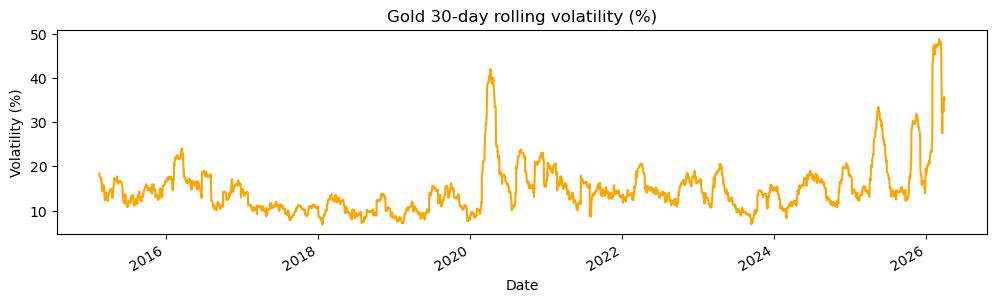

In [24]:

# Rolling volatility (annualized)
df['gold_vol_30d'] = df['gold_return'].rolling(30).std() * np.sqrt(252) * 100
df['gold_vol_30d'].plot(figsize=(12, 3), color='orange', title='Gold 30-day rolling volatility (%)')
plt.ylabel('Volatility (%)')
plt.show()


* จากกราฟ Rolling volatility(annualized) คือ กราฟที่เปลี่ยนจากค่า Standard Deviation ธรรมดามาเป็นการปรับให้เป็นรายปี (Annualized Volatility) ด้วยสูตร S.D. x sqrt(252) x 100 (โดย 252 คือจำนวนวันเทรดใน 1 ปี)

1. จะสังเกตเห็นว่าช่วงที่กราฟอยู่ในระดับต่ำ (เช่น ปี 2016-2019 ที่แกว่งแถวๆ 10-15%) มันก็จะต่ำต่อเนื่องไปยาวๆ แต่พอถึงช่วงที่พุ่งสูง มันก็จะสูงต่อเนื่องเป็นก้อนใหญ่ๆ (เช่น ปี 2020 และช่วง 2025-2026)Insight: ในทางสถิติ สิ่งนี้เรียกว่าปรากฏการณ์ Volatility Clustering (ความผันผวนวันนี้ มักจะส่งผลถึงความผันผวนในวันพรุ่งนี้) ซึ่งตัวแปร gold_vol_30d นี้จะเป็น Feature ที่ช่วยบอกโมเดลได้ว่า ช่วงนี้ตลาดกำลังผันผวนหรือเงียบสงบ
2. ตรงกลางกราฟมีเส้นที่พุ่งสูงมากซึ่งเป็นความผันผวนที่พุ่งไปแตะระดับ 40% นั่นคือช่วงเดือนมีนาคม 2020 ที่เกิดเหตุการณ์ Black Swan ตลาดเทขายทุกสินทรัพย์เพื่อถือเงินสด (Liquidity Crunch) แม้แต่ทองคำก็ร่วงหนักและสวิงรุนแรงมาก
3. กราฟด้านขวาสุดแสดงให้เห็นว่าความผันผวนพุ่งทะลุจุดสูงสุดเดิมไปเกือบ 50% ซึ่งสอดคล้องกับกราฟ gold_close ที่เห็นก่อนหน้านี้ว่าทำ All-time High ต่อเนื่องเป็นเส้นตั้งฉาก นี่คือสภาวะ Regime Shift (การเปลี่ยนโหมดของตลาด)  ตลาดช่วงปี 2025-2026 มีไดนามิกที่ต่างจากช่วง 10 ปีก่อนหน้า


ในส่วนของการ Feature 
* Classification แทนที่คุณจะกำหนด Threshold ของคลาส "Side" เป็นค่าคงที่ ตลอดทั้ง 10 ปี อาจลองใช้ gold_vol_30d มาทำ Dynamic Threshold เเทน เช่น ถ้าช่วงไหน Volatility ต่ำ กรอบ Sideway อาจจะแคบ แต่ถ้า Volatility สูงมาก ก็ให้กรอบของการออกข้างก็ควรจะกว้างขึ้นตามไปด้วย เพื่อให้ Label ของข้อมูลตรงกับความผันผวนในตลาดจริงมากขึ้น 
* Regression (% Return) ในช่วงปี 2025-2026 มันอาจจะทำนายพลาดเยอะมาก (มี Error สูง) แต่ถ้าใส่ตัวแปรความผันผวนนี้เข้าไป โมเดล tree (เช่น Random Forest หรือ XGBoost) จะเรียนรู้ได้ว่า เช่น ถ้าค่า gold_vol_30d > 30% ให้เตรียมใจว่า % Return ของวันพรุ่งนี้จะอาจจะสวิงมากกว่าปกติ

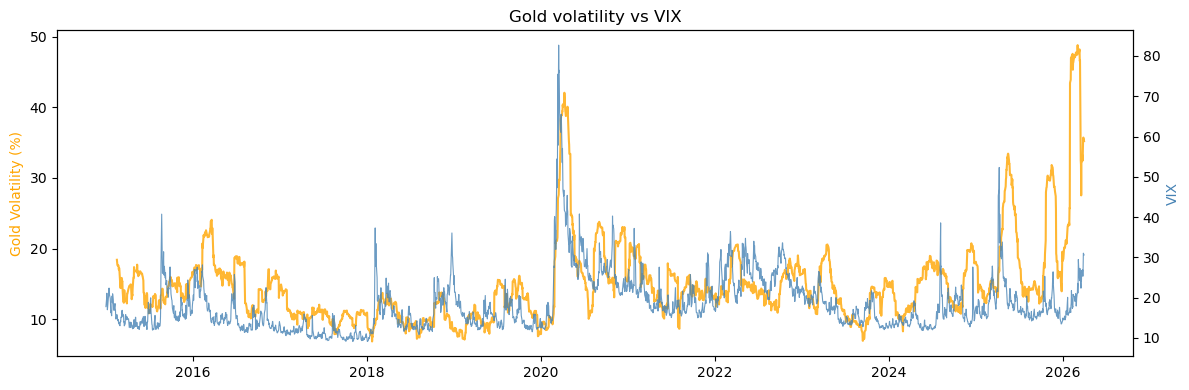

In [25]:
# Gold volatility vs VIX
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(df.index, df['gold_vol_30d'], color='orange', label='Gold vol 30d', alpha=0.8)
ax2.plot(df.index, df['vix_close'], color='steelblue', label='VIX', alpha=0.8, linewidth=0.8)
ax1.set_ylabel('Gold Volatility (%)', color='orange')
ax2.set_ylabel('VIX', color='steelblue')
plt.title('Gold volatility vs VIX')
plt.tight_layout()
plt.show()

* จากกราฟ Gold volatility vs VIX
1. ช่วงวิกฤตโลก (ปี 2020)
จะเห็นได้ว่าเป็นกราฟที่พุ่งสูงปรี๊ดในช่วงตรงกลางของกราฟ คือช่วงที่เกิดโควิด-19 ซึ่งกราฟสีน้ำเงิน (VIX) และสีส้ม (Gold Vol) พุ่งขึ้นทำจุดสูงสุดพร้อมกันเป๊ะๆ ทำให้เห็นว่าในตอนที่เกิด Panic Sell ระดับโลก นักลงทุนจะเทขายทุกอย่างแม้กระทั่งทองคำเพื่อถือเงินสด ทำให้ความผันผวนของทั้งสองตลาดมีความสัมพันธ์กันสูงมาก (Correlation เข้าใกล้ 1)

2. เริ่มเปลี่ยนtrend (Decoupling)  ตั้งเเต่ในช่วงปี 2024 ถึง 2026
ที่ฝั่งขวาสุดของกราฟ จะเห็นว่า VIX (สีน้ำเงิน) แกว่งตัวอยู่ในระดับต่ำถึงปานกลาง (ประมาณ 15-20) บ่งบอกว่าตลาดหุ้นสหรัฐฯ (S&P500) ค่อนข้างชิลและไม่มีความตื่นตระหนก แต่ในขณะเดียวกัน Gold Volatility (สีส้ม) กลับพุ่งขึ้นไปแตะระดับเกือบ 50% ซึ่งสูงกว่าในช่วงวิกฤติโควิด ทำให้เห็นได้ชัดว่า การพุ่งขึ้นของราคาทองคำในรอบนี้ ไม่ได้เกิดจากความกลัวในตลาดหุ้น แต่มันเกิดจากปัจจัยอื่นล้วนๆ (เช่น สงคราม, การกว้านซื้อของธนาคารกลาง หรือปัญหาค่าเงินดอลลาร์) สภาวะนี้เรียกว่า Regime Shift หรือการเปลี่ยนพฤติกรรมของตลาด

* สำหรับในส่วนของ Features 
 
1. Volatility Spread (ส่วนต่างความผันผวน)
สร้างคอลัมน์ใหม่โดยเอา VIX ลบด้วย gold_vol_30d (หรือจับหารกันเป็น Ratio)
เนื่องจากถ้า Spread มีค่าเป็นบวก (VIX สูงกว่า) แปลว่าหุ้นผันผวนกว่าทอง แต่ถ้า Spread ติดลบหนักๆ แบบปี 2026 แปลว่าทองคำกำลังมี ปัจจัยเฉพาะตัวที่ไม่ใช่เเค่ตลาดหุ้น โมเดล Tree-based จะชอบ Feature แบบนี้เพราะมันใช้แยก Node ตัดสินใจ

2. VIX Momentum แทนที่จะดูแค่ค่า VIX  เฉพาะวันนั้นๆ ให้หาอัตราการเปลี่ยนแปลงของ VIX ย้อนหลัง 3 วัน หรือ 5 วัน (vix_pct_change) เพื่อดูว่าความตื่นตระหนกกำลัง เกิดขึ้น หรือ เบาบาง

3. Regime Indicator (ตัวกรองสภาวะตลาด) ให้สร้างตัวแปรแบบ 0 กับ 1 (Binary Feature) ตัวอย่างเช่น ถ้า gold_vol_30d > 25% ให้ค่าเป็น 1 (High Vol Regime) เพื่อส่งสัญญาณให้โมเดล Regression รู้ว่า ช่วงนี้ผลตอบแทนจะสวิงในช่วงที่กว้างเป็นพิเศษ

In [26]:
# Return stats
r = df['gold_return'].dropna()
print(f"Mean return:  {r.mean()*100:.4f}%")
print(f"Std:          {r.std()*100:.4f}%")
print(f"Sharpe (ann): {(r.mean()/r.std())*np.sqrt(252):.2f}")
print(f"Max drawdown: {(df['gold_close']/df['gold_close'].cummax()-1).min()*100:.2f}%")

Mean return:  0.0527%
Std:          1.0264%
Sharpe (ann): 0.82
Max drawdown: -20.87%


- Sharp ratio คือ อัตราส่วนทางการเงินที่วัดความคุ้มค่าของผลตอบแทนเมื่อเทียบกับความเสี่ยง (Risk-Adjusted Return) ยิ่งค่า Sharpe Ratio สูง แสดงว่ากองทุนหรือสินทรัพย์นั้นให้ผลตอบแทนสูงเมื่อเทียบกับความผันผวนที่เกิดขึ้น โดยค่านี้คำนวณจากผลตอบแทนส่วนเกิน (ผลตอบแทนลงทุน - ผลตอบแทนไร้ความเสี่ยง) หารด้วยส่วนเบี่ยงเบนมาตรฐาน

# 6.Volume Analysis

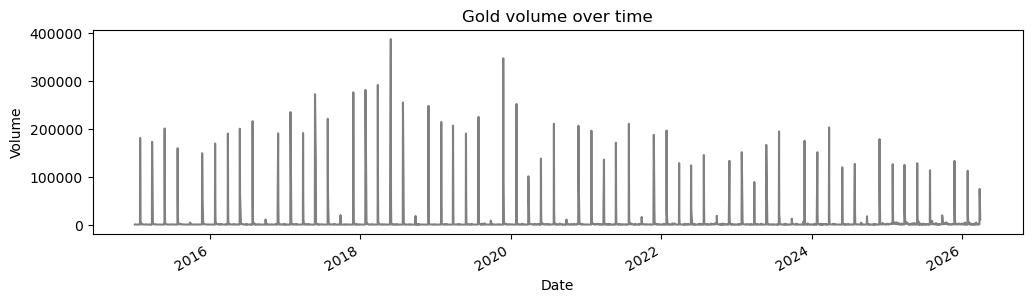

In [27]:
# Gold volume over time
df['gold_vol'].plot(figsize=(12, 3), color='gray', title='Gold volume over time')
plt.ylabel('Volume')
plt.show()

* จากกราฟ Gold Voloume over time 
พบว่าข้อมูลชุดนี้ที่ดึงมาจากสัญญาซื้อขายล่วงหน้า (GC=F) ทองคำจะมีรอบส่งมอบสัญญาหลักๆ ปีละประมาณ 6 ครั้ง (เช่น ก.พ., เม.ย., มิ.ย., ส.ค., ธ.ค.) ช่วงที่สัญญากำลังจะหมดอายุ นักลงทุนระดับโลกจะทำการปิดสัญญาเก่า แล้วแห่ไปเปิดสัญญาเดือนถัดไปพร้อมๆ กัน ทำให้ Volume ในช่วงวันนั้นพุ่งขึ้นเป็นหลักแสนสัญญา แต่พอเป็นวันปกติ แหล่งข้อมูลอาจจะไม่ได้รวม Volume ของทุกสัญญาย่อยๆ เข้าด้วยกัน ค่าเลยออกมาต่ำอย่างที่เห็น

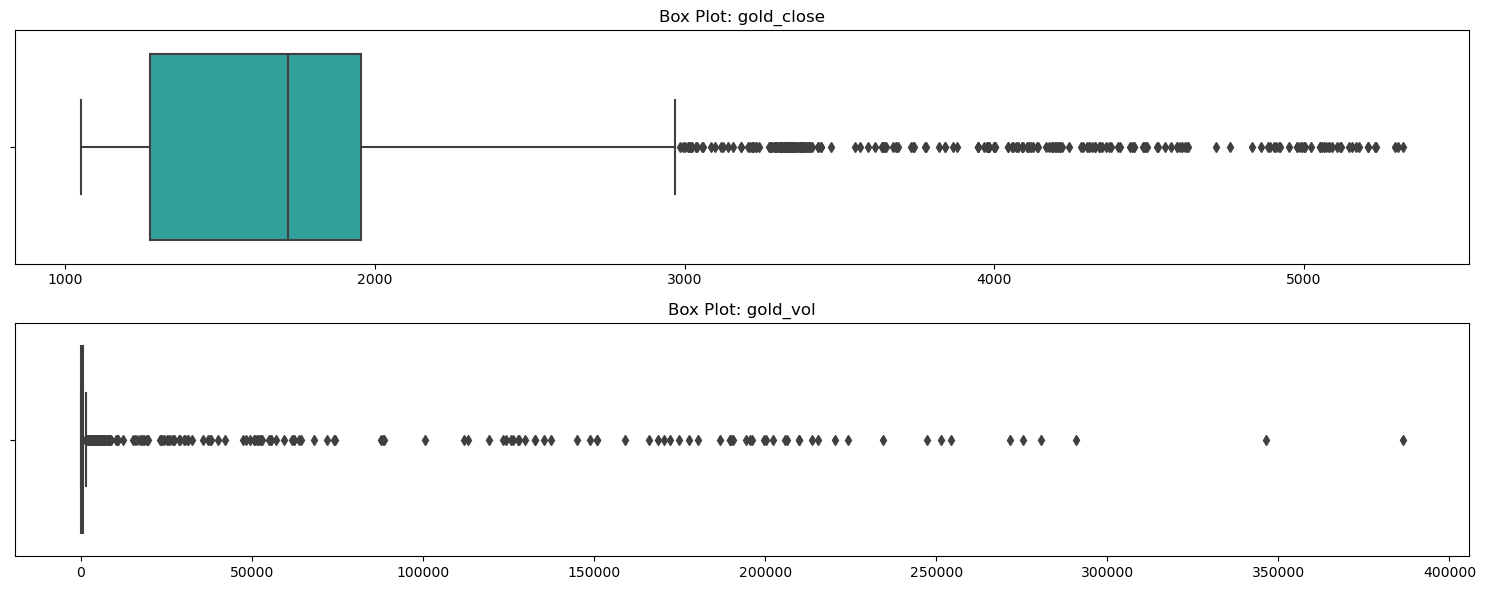

In [28]:
cols_to_plot = ['gold_close', 'gold_vol']

n_cols = 1
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color='lightseagreen')
    axes[i].set_title(f'Box Plot: {col}', fontsize=12)
    axes[i].set_xlabel('')

for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* กราฟ box plot
พบว่ากล่องสี่เหลี่ยม (IQR) แทบจะแบนราบเป็นเส้นตรงเดียวกับแกน 0 ในขณะที่จุด Outliers กระจายตัวห่างออกไปไกลลิบถึงเกือบ 400,000  ทำให้เห็นว่าข้อมูลส่วนใหญ่กระจุกตัวอยู่ที่หลักร้อยถึงหลักพัน (กล่องเลยแคบมาก) แต่มีบางวันที่ Volume พุ่งไปหลักแสน ทำให้เกิดปัญหา คือ ข้อมูลที่มีการกระจายตัวเบบเบ้ขวาอย่างมาก ซึ่งแบบนี้ จะทำให้โมเดล Regression พังทลายได้ง่ายมาก เพราะโมเดลจะพยายามไปเรียนรู้น้ำหนักจากแท่งหลักแสนพวกนี้ จนลืมสนใจในวันที่ตลาดปกติ

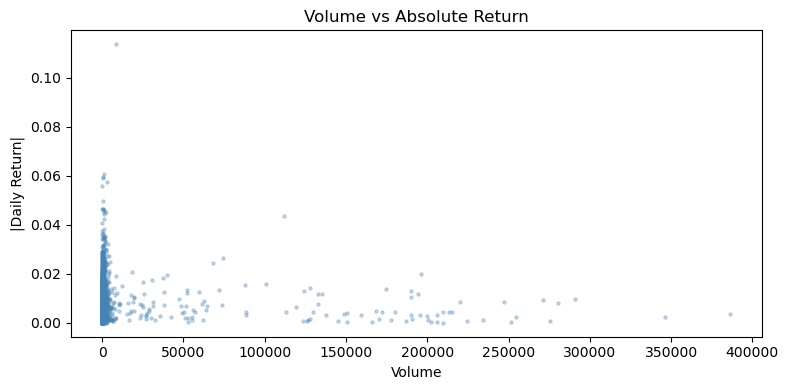

In [29]:
# Volume vs price change
df['abs_return'] = df['gold_return'].abs()

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['gold_vol'], df['abs_return'], alpha=0.3, s=5, color='steelblue')
ax.set_xlabel('Volume')
ax.set_ylabel('|Daily Return|')
ax.set_title('Volume vs Absolute Return')
plt.tight_layout()
plt.show()

* กราฟ Volume vs Absolute Return
ปกติแล้วการนำ Volume มาเทียบกับ Absolute Return (ขนาดของการแกว่งตัว) เพื่อดูว่าวันไหนที่มีแรงซื้อ-ขายเยอะๆ ราคามันจะแกว่งแรงตามไปด้วยหรือไม่ ซึ่งในตลาดการเงินจริงๆ กราฟควรจะมีทิศทางกระจายตัวเฉียงขึ้นไปทางขวาบน (ราคาเหวี่ยงแรง = วอลลุ่มพุ่ง) แต่กราฟนี้กลับฟ้องว่าข้อมูลของเรากำลังสวนทางกับทฤษฎีโดยสิ้นเชิง
ทำให้มั่นใจได้ว่ายอด Volume หลักแสนพวกนี้ ไม่ใช่แรงซื้อขายที่เกิดจาก Demand/Supply จริงๆ ในตลาด แต่มันคือ ธุรกรรมเชิงระบบ เช่น วันหมดอายุแล้วย้ายสัญญา (Contract Rollover)หรือเป็นเพียงความคลาดเคลื่อนของการรวมข้อมูลรายเดือนจากแหล่งที่มาของ Data

#### ก่อนนำข้อมูบไปใช้ 

ควรเอาคอลัมน์ gold_vol ออก หรือต้องปรับเเก้ไขอะไรซักอย่างให้ข้อมูลเป็นปกติที่สุด เนื่องจากถ้าเอาข้อมูลนี้เข้าไปตรงๆ โมเดลทั้ง Regression และ Classification จะเกิดความสับสนอย่างหนัก เพราะมันจะถูกหลอกให้จำว่าเวลามีวอลลุ่มเข้าเยอะๆ แปลว่าตลาดจะไม่มีทิศทาง (ทรงตัว)

In [30]:
# Correlation: volume vs |return|
corr_val = df[['gold_vol','abs_return']].corr().iloc[0,1]
print(f"Correlation (volume vs |return|): {corr_val:.4f}")

Correlation (volume vs |return|): -0.0246


1. ค่า Correlation ที่ -0.0246 นั้นถือว่าเข้าใกล้ศูนย์มากๆ ในทางสถิติแปลว่า ตัวแปรสองตัวนี้ไม่มีความเกี่ยวข้องกันแบบเส้นตรงเลย ทำให้บอกได้ว่าการที่ Volume ของ gold เพิ่มขึ้น ไม่ได้ช่วยบอกเลยว่าราคาจะแกว่งกว้างขึ้นหรือแคบลง

In [31]:
# High volume days
vol_threshold = df['gold_vol'].quantile(0.95)
high_vol = df[df['gold_vol'] >= vol_threshold][['gold_close','gold_vol','gold_return']]
print(f"\nTop 5% volume days ({len(high_vol)} rows):")
print(high_vol.sort_values('gold_vol', ascending=False).head(10))


Top 5% volume days (142 rows):
             gold_close  gold_vol  gold_return
Date                                          
2018-05-29  1298.699951    386334    -0.003530
2019-11-26  1459.800049    346362     0.002197
2018-03-27  1341.300049    290889    -0.009672
2018-01-26  1351.599976    280546    -0.007927
2017-11-28  1294.699951    275442     0.000696
2017-05-26  1267.599976    271457     0.009396
2018-07-27  1222.599976    254428    -0.002204
2020-01-29  1569.800049    251274     0.000382
2018-11-28  1221.400024    247168     0.008421
2017-01-27  1188.099976    234352    -0.001177


1. วันที่มี Volume มหาศาลเหล่านี้ กระจุกตัวอยู่ในช่วงวันที่ 26 - 29 ของเดือนแทบจะ 100% เลย เเสดงให้เห็นว่า มันคือ วันหมดอายุสัญญา กองทุนต่างๆแค่สับเปลี่ยนสัญญาเก่าที่กำลังจะหมดอายุ ไปถือสัญญาของเดือนถัดไป Volume เลยสูงผิดปกติ แต่ไม่ได้เกิดจากการแห่ซื้อขายเพราะมีข่าวเศรษฐกิจจริงๆ

2.  ในขณะที่ Volume พุ่งไป 200,000 - 300,000 สัญญา (สูงกว่าวันปกติเป็นพันเท่า) แต่ค่า Return กลับขยับเพียงแค่นิดเดียว เช่น -0.0035 (-0.35%) หรือ 0.0021 (+0.21%) ซึ่งถือว่าแทบจะย่ำอยู่กับที่เลย ทำให้ให้ได้ว่าการยืนยันกราฟ Scatter Plot รูปตัว L ด้านบน บอกได้ว่า วอลลุ่มกลุ่มนี้ ไม่มีผลกระทบต่อทิศทางราคาอย่างมีนัยสำคัญ

#### Note:
ในขั้นตอนสุดท้ายที่คุณต้องเอาสัญญาณจาก ML (Up/Down) มาสร้างระบบเทรด สามารถเขียนไว้ได้ว่า หากเป็นช่วงวันที่ 26-29 ของเดือน (หรือวันที่คาดว่าจะเป็น Rollover) ให้ระงับการเทรด (Force HOLD) เลย เนื่องจากเป็นช่วงที่ตลาดมักจะทรงตัว หรือมี Noise ของระบบเยอะ

# 7.Cross-Asset Analysis

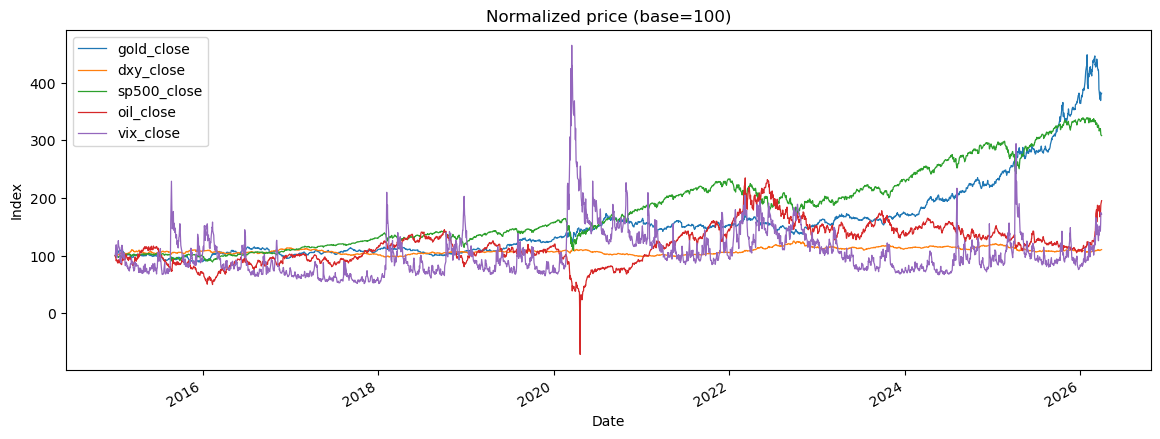

In [32]:
# Normalize all assets to 100 at start
asset_cols = ['gold_close','dxy_close','sp500_close','oil_close','vix_close']
df_norm = df[asset_cols].dropna().apply(lambda x: x / x.iloc[0] * 100)

df_norm.plot(figsize=(14, 5), linewidth=0.9)
plt.title('Normalized price (base=100)')
plt.ylabel('Index')
plt.legend(loc='upper left')
plt.show()


* จากกราฟ Normalized price (base=100)
พบว่า 
1. ตลอดช่วงปี 2015 ถึง 2023 ตลาดหุ้นสหรัฐฯ (สีเขียว) เป็นผู้ชนะมาตลอด เติบโตทิ้งห่างทองคำไปไกลมาก แต่พอเข้าสู่ช่วงปี 2024-2026 ราคาทองคำกลับพุ่งทะยานแบบพาราโบลา จนเส้นสีฟ้าวิ่งขึ้นมาแซงชนะผลตอบแทนสะสมของตลาดหุ้น  ซึ่งสภาวะที่ทองคำ Outperform ตลาดหุ้นแบบนี้เกิดขึ้นไม่บ่อย เเละมันคือหลักฐานยืนยัน Regime Shift ว่าเม็ดเงินในตลาดโลกกำลังไหลออกจากสินทรัพย์เสี่ยงเข้าสู่ทองคำ

2. ในส่วนของเส้นสีส้ม(DXY) เเสดงให้เห็นถึงธรรมชาติของสกุลเงิน ที่มันไม่ได้มีกลไกการเติบโตทบต้น เหมือนบริษัทในตลาดหุ้น หรือมีความเป็นสินค้าโภคภัณฑ์เหมือนทองคำ ดังนั้น ในการทำโมเดล อาจจะเปลี่ยนจาก DXY เพียวๆ เป็น % Change เพราะสเกลการสวิงมันเล็กมากเมื่อเทียบกับตัวอื่น

3. เส้นสีม่วง(vix) เเละเส้นสีเเดง (oil) 2 ตัวนี้มีพฤติกรรม Mean Reversion (กลับคืนสู่ค่าเฉลี่ย) เหมาะที่จะเอามาทำเป็น สัญญาณเตือนภัย (Warning Signals) ให้กับโมเดล


* Feature Engineer สร้างตัวแปร Relative Strength

เช่น Gold-to-SP500 Ratio: df['gold_sp500_ratio'] = df['gold_close'] / df['sp500_close'] เนื่องจาก หาก Ratio นี้กำลังโค้งหัวขึ้น แปลว่าทองคำกำลังแข็งแกร่งกว่าหุ้น โมเดลจะสามารถเรียนรู้เทรนด์การย้ายเงินทุนของนักลงทุนระดับโลกได้

Oil-to-Gold Ratio: นำราคาน้ำมันหารด้วยราคาทองคำ เพื่อเป็นตัวแทนของการเเสดงเงินเฟ้อ

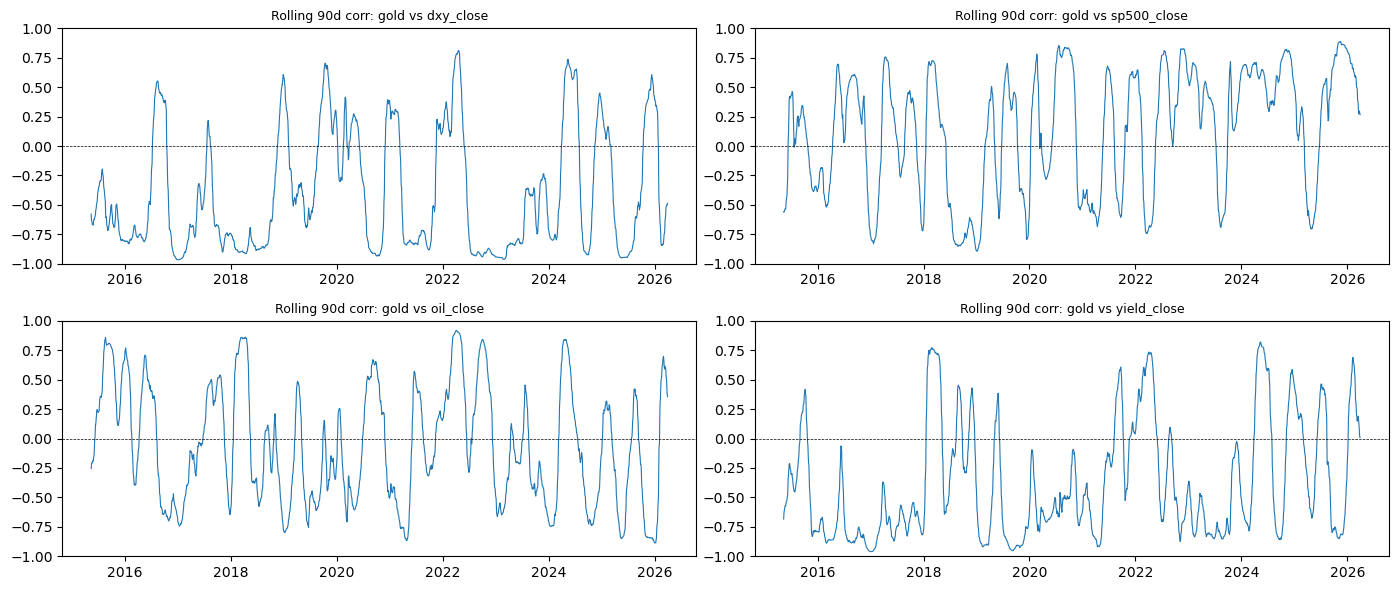

In [33]:
# Rolling 90-day correlation: gold vs each asset
roll_cols = ['dxy_close','sp500_close','oil_close','yield_close']
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(roll_cols):
    r = df['gold_close'].rolling(90).corr(df[col])
    axes[i].plot(df.index, r, linewidth=0.8)
    axes[i].axhline(0, color='black', linewidth=0.5, linestyle='--')
    axes[i].set_title(f'Rolling 90d corr: gold vs {col}', fontsize=9)
    axes[i].set_ylim(-1, 1)
plt.tight_layout()
plt.show()


1. หักล้างทฤษฎีดอลลาร์และดอกเบี้ย (DXY & Yield)
ตามทฤษฎี: ทองคำต้องวิ่งสวนทางกับดอลลาร์และผลตอบแทนพันธบัตร (Correlation ควรติดลบตลอดเวลา)
ความจริงในกราฟ: ดูที่เส้นประ 0.0 แม้ว่าส่วนใหญ่กราฟจะอยู่โซนติดลบ (แปลว่าวิ่งสวนทางกันจริง) แต่จะเห็น Spike ที่พุ่งทะลุ 0 ขึ้นไปแดนบวกสูงมากในหลายๆ ช่วง (เช่น ปี 2019, 2023, 2025)
ซึ่งทำให้เห็นว่า ช่วงที่ Correlation พุ่งเป็นบวก คือสภาวะผิดปกติ (Regime Shift) ที่

2. ทองเทียบ S&P500 
S&P500 มันแกว่งจาก -0.8 ขึ้นไป +0.8 แล้วกลับลงมาใหม่เป็นรอบๆ ทำให้เห็นว่า ความสัมพันธ์ของทองคำกับตลาดหุ้น ไม่มีความคงที่เลยแม้แต่นิดเดียว (Highly Non-stationary) บางไตรมาสก็จับมือกันขึ้น บางไตรมาสก็วิ่งสวนทางกันเด็ดขาด การใช้ข้อมูลดิบๆ ไปโยนใส่โมเดลโดยไม่บอกบริบทเหล่านี้ อาจทำให้โมเดลเกิดความสับสนและทำนายพลาด

* feature engineer
เช่น สร้างตัวแปร corr_90d_dxy และ corr_90d_sp500 ใส่เข้าไปจะทำให้
โมเดล tree สามารถเรียนรู้เงื่อนไขที่ซับซ้อนได้ (เช่น ถ้าวันนี้ SP500 ร่วงแรง แต่ค่า corr_90d_sp500 ช่วงนี้ค่ามันติดลบ (-0.6) แปลว่าตลาดทองวิ่งสวนทางหุ้น)

🚨 จุดที่ต้องระวัง (Pro-Tip สำหรับ Pipeline)
โค้ดที่ใช้ คือ df['gold_close'].rolling(90).corr() ซึ่งเป็นการหาความสัมพันธ์จาก ราคาดิบ ให้ลองเปลี่ยนจากการใช้ ราคาดิบ เป็น % Return แทน

ซึ่งการหา Rolling Correlation จากผลตอบแทน (Return) จะสะท้อนพฤติกรรมการเกาะกลุ่มรายวันได้ชัดกว่าการหาราคาดิบที่แฝงเรื่อง Trend เอาไว้

In [34]:
# Summary table
print("Cross-asset correlation with gold_close:")
print(df[['gold_close'] + roll_cols].corr()['gold_close'].drop('gold_close').round(3))

Cross-asset correlation with gold_close:
dxy_close      0.277
sp500_close    0.907
oil_close      0.296
yield_close    0.564
Name: gold_close, dtype: float64


* จากการรวมข้อมูลทั้งหมดมารวบยอดบีบอัดให้เหลือแค่ ตัวเลขกลมๆเพียงค่าเดียว(Global Correlation) เเล้วนำมาเทียบกับ กราฟ Rolling 90 วัน ทำให้เห็นว่า 
1. ข้อมูลนี้บอกว่าตลอด 10 ปี หุ้นกับทองคำขึ้นพร้อมกัน (0.907) แต่กราฟ Rolling 90 วันเมื่อกี้ทำให้เห็นว่า มีหลายช่วงเวลาที่ความสัมพันธ์ดิ่งลงไปติดลบ -0.8 เพราะฉะนั้นการเชื่อตัวเลข 0.907 นี้เพียงค่าเดียว จะทำให้โมเดลเกิด Bias ว่าหุ้นขึ้นแล้วทองต้องขึ้นตามเสมอ

2. ตามหลักเศรษฐศาสตร์ ดอกเบี้ยขึ้น ทองต้องลง (ควรติดลบ) แต่ตารางนี้กลับโชว์ค่าเป็นบวก (0.564) สาเหตุเพราะมันถูก น้ำหนักของข้อมูลช่วงปี 2022-2026 (สภาวะ Regime Shift ที่ยีลด์และทองพุ่งขึ้นพร้อมกัน) ดึงค่าเฉลี่ยของทั้งทศวรรษให้มั่วไปหมด

3.gold กับ dxy_close (0.277) และ oil_close (0.296) ตัวเลขดูเหมือนจะมีความสัมพันธ์กันต่ำมาก แต่จริงๆ แล้วมันมีความสัมพันธ์แบบ สวิงไปสวิงมา (Cyclical) ตามที่เราเห็นในกราฟ พอเอามาหาค่าเฉลี่ยรวบยอด 10 ปี ค่าบวกกับค่าลบมันเลยหักล้างกันเองจนเหลือแค่ 0.2 กว่าๆ 

* พบว่า
1. ข้อมูลมี Trend สูงมาก (ต้องแปลงเป็น % Return ไม่ให้โมเดลเรียนรู้จากราคาดิบ (Raw Prices))

2. มี Noise จาก gold_vol มาก

3. มีจุด Outlier จาก Black Swan Events

4. มีการเปลี่ยนพฤติกรรมตลาด หรือ Regime Shift (VIX สงบ แต่ทองผันผวน)

# 8.Missing Values & Data Quality

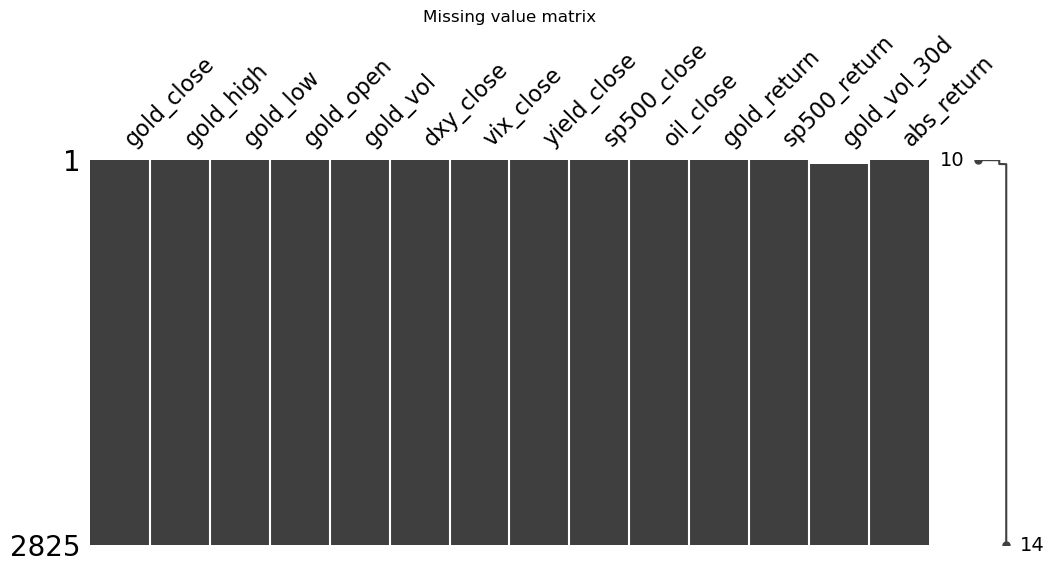

In [35]:
# Missing value heatmap
msno.matrix(df, figsize=(12, 5))
plt.title('Missing value matrix')
plt.show()

คอลัมน์ที่มีข้อมูลหาย คือ
1. คอลัมน์: gold_return, sp500_return, abs_return

เกิดจากการใช้คำสั่ง .pct_change() เนื่องจากข้อมูลวันแรกสุดของตาราง (2 ม.ค. 2015) ไม่มีข้อมูลของเมื่อวานให้เปรียบเทียบหาเปอร์เซ็นต์การเปลี่ยนแปลง ค่าในแถวแรกจึงกลายเป็น NaN ทันที

2. คอลัมน์: gold_vol_30d หายไป 29 แถวแรก

เกิดจากการใช้หน้าต่างคำนวณย้อนหลัง หรือ .rolling(30) ครับ โมเดลจำเป็นต้องรอให้เก็บข้อมูลครบ 30 วันก่อนถึงจะคำนวณค่าความผันผวนก้อนแรกออกมาได้ ทำให้ข้อมูลในช่วง 29 วันแรกของตารางเป็นค่า NaN ทั้งหมด

In [36]:
# Date gaps (missing trading days)
full_range = pd.date_range(df.index.min(), df.index.max(), freq='B')  # business days
missing_dates = full_range.difference(df.index)
print(f"Missing business days: {len(missing_dates)}")
if len(missing_dates) > 0:
    l = missing_dates[:20].tolist()
    print("วันหยุด 20 รายการเเรก")
    for i in l:
        print(i)

Missing business days: 107
วันหยุด 20 รายการเเรก
2015-01-19 00:00:00
2015-02-16 00:00:00
2015-04-03 00:00:00
2015-05-25 00:00:00
2015-07-03 00:00:00
2015-09-07 00:00:00
2015-11-26 00:00:00
2015-12-25 00:00:00
2016-01-01 00:00:00
2016-01-18 00:00:00
2016-02-15 00:00:00
2016-03-25 00:00:00
2016-05-30 00:00:00
2016-07-04 00:00:00
2016-09-05 00:00:00
2016-10-10 00:00:00
2016-11-11 00:00:00
2016-11-24 00:00:00
2016-12-26 00:00:00
2017-01-02 00:00:00


- มีวันที่หายไป 107 วันตลอด 10 กว่าปีนี้ (เฉลี่ยปีละ 9-10 วัน) คือ วันหยุดทำการของตลาดหลักทรัพย์สหรัฐฯ (US Market Holidays)
- #### สิ่งที่ต้องระวัง
1. ใช้คำสั่ง .shift(1) เพื่อดึงราคาของ เมื่อวาน มาทาย วันนี้ ตรงๆไม่ได้เนื่องจากถ้าวันหยุดคือวันจันทร์ ในวันอังคารตลาดเปิด เเต่เมื่อจะเอาราคาล่าสุดมาทำนาย พบว่าต้องใช้ราคาของวันศุกร์(เสาร์-อาทิตย์ตลาดปิด) ซึ่งมันห่างจากวันอังคารประมาณ 4 วัน ซึ่งในช่วงนี้อาจเกิดเหตุการณ์ต่างๆที่ผลกระทบต่อทองคำมากๆได้
2. ห้ามใช้เทคนิค Interpolation (การเติมค่าเฉลี่ย) หรือ Forward Fill (ดึงราคาเก่ามาเติม) เพื่อบังคับให้ปฏิทินมันเต็มทุกวันทำการเด็ดขาด เพราะในความเป็นจริง วันหยุดคือวันที่คุณไม่สามารถส่งคำสั่ง BUY/SELL ได้

#### feature engineering
สร้าง Feature ที่ชื่อว่า days_since_last_trade (จำนวนวันที่ห่างจากการเทรดครั้งล่าสุด)

- วันอังคาร-ศุกร์ ปกติ ค่า = 1

- วันจันทร์ (หลังเสาร์อาทิตย์) ค่า = 3

- วันอังคาร (หลังหยุดยาว) ค่า = 4

ข้อดี: เมื่อโมเดล Tree-based เห็นว่าค่านี้ > 1 มันจะรู้ว่า ให้ระวังนะ วันนี้ราคาอาจจะกระโดด (Gap Up/Down) หรือแกว่งแรงกว่าปกติ เเละ ช่วยให้โมเดล Regression ปรับค่า Error ได้ดีขึ้น และโมเดล Classification ทายจังหวะ Breakout ได้แม่นขึ้น

In [37]:
# Check value range consistency
print("\nValue range check:")
expected = {
    'vix_close': (5, 90),
    'yield_close': (0, 20),
    'dxy_close': (50, 150),
    'gold_close': (200, 5500),
    'oil_close': (-10, 200),
}
for col, (lo, hi) in expected.items():
    if col in df.columns:
        out = df[(df[col] < lo) | (df[col] > hi)][col]
        print(f"  {col:<20} range=[{lo},{hi}]  anomalies={len(out)}")


Value range check:
  vix_close            range=[5,90]  anomalies=0
  yield_close          range=[0,20]  anomalies=0
  dxy_close            range=[50,150]  anomalies=0
  gold_close           range=[200,5500]  anomalies=0
  oil_close            range=[-10,200]  anomalies=1


In [38]:
# Zero or negative prices
for col in cols:
    n_zero = (df[col] <= 0).sum()
    if n_zero > 0:
        print(f"  WARN: {col} has {n_zero} zero/negative values")

  WARN: oil_close has 1 zero/negative values


# 9. Clean Data Part2

เคลียร์ Outliner และ คำนวณ %return

In [39]:
# 1. Calculate %return for all asset columns
for col in ['gold_close','dxy_close','vix_close','yield_close','sp500_close','oil_close']:
    df[f'{col}_ret'] = df[col].pct_change() * 100

# 2. Remove outliers (IQR method) for all price columns
for col in ['gold_close','dxy_close','vix_close','yield_close','sp500_close','oil_close']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)
    df = df[~outlier_mask]

# 3. Clean gold_vol (remove outlier, fill missing)
vol_col = 'gold_vol'
Q1 = df[vol_col].quantile(0.25)
Q3 = df[vol_col].quantile(0.75)
IQR = Q3 - Q1
vol_outlier_mask = (df[vol_col] < Q1-1.5*IQR) | (df[vol_col] > Q3+1.5*IQR)
df.loc[vol_outlier_mask, vol_col] = np.nan
# fill missing with median
df[vol_col] = df[vol_col].fillna(df[vol_col].median())

# Reset index after cleaning
df = df.sort_index()

print('Cleaned Data Shape:', df.shape)
df.head()

Cleaned Data Shape: (2455, 20)


,gold_close,gold_high,gold_low,gold_open,gold_vol,dxy_close,vix_close,yield_close,sp500_close,oil_close,gold_return,sp500_return,gold_vol_30d,abs_return,gold_close_ret,dxy_close_ret,vix_close_ret,yield_close_ret,sp500_close_ret,oil_close_ret
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138.0,91.080002,17.790001,2.123,2058.199951,52.689999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470.0,91.379997,19.920000,2.039,2020.579956,50.040001,0.015093,-0.018278,NaN,0.015093,1.509277,0.329376,11.973013,-3.956659,-1.827811,-5.029413
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97.0,91.500000,21.120001,1.963,2002.609985,47.930000,0.012792,-0.008893,NaN,0.012792,1.279178,0.131323,6.024100,-3.727316,-0.889347,-4.216628
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29.0,91.889999,19.309999,1.954,2025.900024,48.650002,-0.007135,0.011630,NaN,0.007135,-0.713530,0.426229,-8.570082,-0.458485,1.162984,1.502193
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92.0,92.370003,17.010000,2.016,2062.139893,48.790001,-0.001817,0.017888,NaN,0.001817,-0.181724,0.522367,-11.910923,3.172980,1.788828,0.287769


In [ ]:
# แสดงจำนวน NaN ในแต่ละคอลัมน์
print('Missing values per column:')
display(df.isnull().sum())

# จัดการ NaN ด้วยการใช้ค่า median ของแต่ละคอลัมน์
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print('Missing values after fill:')
display(df.isnull().sum())

df.head()

Missing values per column:


gold_close          0
gold_high           0
gold_low            0
gold_open           0
gold_vol            0
dxy_close           0
vix_close           0
yield_close         0
sp500_close         0
oil_close           0
gold_return         1
sp500_return        1
gold_vol_30d       30
abs_return          1
gold_close_ret      1
dxy_close_ret       1
vix_close_ret       1
yield_close_ret     1
sp500_close_ret     1
oil_close_ret       1
dtype: int64

Missing values after fill:


gold_close         0
gold_high          0
gold_low           0
gold_open          0
gold_vol           0
dxy_close          0
vix_close          0
yield_close        0
sp500_close        0
oil_close          0
gold_return        0
sp500_return       0
gold_vol_30d       0
abs_return         0
gold_close_ret     0
dxy_close_ret      0
vix_close_ret      0
yield_close_ret    0
sp500_close_ret    0
oil_close_ret      0
dtype: int64

,gold_close,gold_high,gold_low,gold_open,gold_vol,dxy_close,vix_close,yield_close,sp500_close,oil_close,gold_return,sp500_return,gold_vol_30d,abs_return,gold_close_ret,dxy_close_ret,vix_close_ret,yield_close_ret,sp500_close_ret,oil_close_ret
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138.0,91.080002,17.790001,2.123,2058.199951,52.689999,0.000443,0.000733,13.310868,0.004729,0.044333,0.009489,-0.729132,0.000000,0.073309,0.178226
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470.0,91.379997,19.920000,2.039,2020.579956,50.040001,0.015093,-0.018278,13.310868,0.015093,1.509277,0.329376,11.973013,-3.956659,-1.827811,-5.029413
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97.0,91.500000,21.120001,1.963,2002.609985,47.930000,0.012792,-0.008893,13.310868,0.012792,1.279178,0.131323,6.024100,-3.727316,-0.889347,-4.216628
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29.0,91.889999,19.309999,1.954,2025.900024,48.650002,-0.007135,0.011630,13.310868,0.007135,-0.713530,0.426229,-8.570082,-0.458485,1.162984,1.502193
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92.0,92.370003,17.010000,2.016,2062.139893,48.790001,-0.001817,0.017888,13.310868,0.001817,-0.181724,0.522367,-11.910923,3.172980,1.788828,0.287769
